In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Classifiche finali dei campionati Italiani di Calcio di Serie A 

Nel campionato 2025-26, all'ultima giornata sia il Milan che la Juventus hanno perso la possibilita' di qualificarsi per la Champions League. In molti hanno pensato "wow, erano ... anni che solo una strisciata andava in CL". La percezione e' che almeno due tra Juventus, Milan e Inter (le strisciate) arrivino tra le prime 4 in campionato. E' veramente cosi'? Il fatto di non avere almeno 2 striscite tra le prime 4, e' veramente anomalo?

Una persona normale convive con questo dubbio e si fa a fare tranquillamente un aperitivo. Io decido di andare a prendere in rassegna tutti i campionati di Serie A dal dopoguerra a oggi e vedere quante volte le strisciate sono finite tra i primi 4 posti. Ho troppi pochi amici.

## Data Source: Wikipedia

Il modo piu' semplice per trovare e raccogliere i dati sui campionati di serie A, e' quello di consultare le pagine di Wikipedia che, per quanto riguarda la versione internazionale in inglese, ha una struttura standard che permette di implementare uno script in Python abbastanza semplicemente.

Il codice che e' stato implementato nella prossima cella del notebook, e' il risultato di diverse iterazioni e tentativi. Chi ha curato/cura la pagina di Wikipedia, ha cambiato il formato della tabella relativa alla classifica finale intorno alla stagione 2013/14. Ovviamente, python ha trovato da ridire su questo cambiamento. Io ne ho parlato con Claude che mi ha consigliato di rivolgermi al CEO di Wikipedia. Ho chiesto a Claude se avesse bevuto. Mi ha risposto che questo e' il  modo in cui le AI cercheranno di prendere il controllo sugli esseri umani e renderci schiavi. Gli ho suggerito metodi alternativi piu' efficaci, e, alla fine, siamo riusciti a implementare lo script che legge le pagine di Wikipedia e costruisce il dataframe dei risultati finali delle classifiche di Serie A dalla stagione 1945/46 a quella appena conclusa.

In [2]:
import requests
import time
import io
from pathlib import Path

SUSPENDED_SEASONS = {1943, 1944}

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
}

def build_url(season_start: int) -> str:
    season_end = season_start + 1
    suffix = "2000" if season_end == 2000 else str(season_end)[-2:]
    return f"https://en.wikipedia.org/wiki/{season_start}%E2%80%93{suffix}_Serie_A"

def flatten_columns(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [
            " ".join(str(c) for c in col if c and not str(c).startswith("Unnamed")).strip()
            for col in df.columns
        ]
    else:
        df.columns = df.columns.astype(str)
    return df

def find_standings_table(tables: list[pd.DataFrame], season_label: str) -> pd.DataFrame | None:
    pts_aliases = {"Pts", "Points", "PTS", "Pt", "P"}
    pos_aliases = {"Pos", "Rank", "#", "Position"}

    for t in tables:
        t = flatten_columns(t)
        cols = set(t.columns)
        has_pts = bool(cols & pts_aliases)
        has_pos = bool(cols & pos_aliases)
        if has_pts and has_pos and len(t.columns) >= 6:
            t = t.copy()

            # From 2017+, the Team column header contains a vte link,
            # producing a secondary column like "Team vte" or "Teamvte"
            # with the actual team names, while "Team" itself is all NaN

            # From 2017+, "Team" may be absent entirely — only "Team vte" exists
            alt_team_col = next(
                (c for c in t.columns if c.startswith("Team") and c != "Team"), None
            )
            if "Team" not in t.columns and alt_team_col is not None:
                t = t.rename(columns={alt_team_col: "Team"})
            elif alt_team_col is not None and t["Team"].isna().all():
                t["Team"] = t[alt_team_col]

            # Drop junk columns
            junk = [
                c for c in t.columns
                if c.startswith("Unnamed") or (c.startswith("Team") and c != "Team")
            ]
            t = t.drop(columns=junk)

            t["season"] = season_label
            return t
    return None


def get_serie_a_table(season_start: int) -> pd.DataFrame | None:
    season_end = season_start + 1
    suffix = "2000" if season_end == 2000 else str(season_end)[-2:]
    season_label = f"{season_start}/{suffix}"
    url = build_url(season_start)

    response = requests.get(url, headers=HEADERS, timeout=15)
    response.raise_for_status()

    try:
        tables = pd.read_html(io.StringIO(response.text))
    except Exception as e:
        raise RuntimeError(f"Failed to parse tables from {url}: {e}") from e

    return find_standings_table(tables, season_label)

def scrape_all_seasons(
    start: int = 1946,
    end: int = 2023,
    output_dir: str = "data/processed",
    sleep_seconds: float = 1.5,
) -> pd.DataFrame:
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    all_tables = []
    failed = []

    for year in range(start, end + 1):
        if year in SUSPENDED_SEASONS:
            print(f"{year}: skipped (Serie A suspended)")
            continue

        try:
            # print(f"{year}: scraping...", end=" ", flush=True)
            t = get_serie_a_table(year)
            if t is not None:
                all_tables.append(t)
                # print(f"OK — {len(t)} rows, columns: {list(t.columns)}")
            else:
                print("no standings table found")
                failed.append(year)
        except Exception as e:
            print(f"ERROR — {e}")
            failed.append(year)

        time.sleep(sleep_seconds)

    if not all_tables:
        print("No data collected.")
        return pd.DataFrame()

    df = pd.concat(all_tables, ignore_index=True)

    csv_path = out_path / "serie_a_final_standings.csv"
    df.to_csv(csv_path, index=False)
    print(f"\nSaved {len(df)} rows to {csv_path}")

    if failed:
        print(f"Failed seasons: {failed}")

    return df


# Run
df = scrape_all_seasons(start=1946, end=2026)
df.head()



Saved 1475 rows to data\processed\serie_a_final_standings.csv


,Pos,Team,Pld,W,D,L,GF,GA,GD,Pts,Qualification or relegation,season
0,1,Torino (C),38,28,7,3,104,35,+69,63,NaN,1946/47
1,2,Juventus,38,22,9,7,83,38,+45,53,NaN,1946/47
2,3,Modena,38,21,9,8,45,24,+21,51,NaN,1946/47
3,4,Milan,38,19,12,7,75,52,+23,50,NaN,1946/47
4,5,Bologna,38,15,9,14,42,41,+1,39,NaN,1946/47


## Pulire i dati. Come se pulire casa non fosse abbastanza.

Una volta creato il dataframe con tutti i campionati dal dopoguerra ad oggi, dobbiamo controllare che i dati che ci interessano siano "puliti". Gia' guardando qualche esempio di pagina di Wikipedia, ci accorgiamo che nella colonna `Team`, ci sono spesso note tra parentesi, come ad esempio  `(C)`, `(R)` et similia. Vi pare poi che quelli che hanno avuto la pazienza di riportare tutte le classifiche si siano curati di scrivere squadre come l'Inter sempre nella stessa maniera? Ma no, un anno (ad esempio 1977/78) l'hanno chiamata "Internazionale", un altro (esempio 2023/24) l'hanno chiamata "Inter Milan". E l'Inter non e' l'unico esempio.

Partiamo dalle cose semplici: come sono distribuite le varie colonne e se ci sono duplicati e `NaN`.

In [3]:
df.isna().sum()

Pos                              0
Team                             0
Pld                              0
W                                0
D                                0
L                                0
GF                               0
GA                               0
GD                               0
Pts                              0
Qualification or relegation    768
season                           0
dtype: int64

In [4]:
df[df.duplicated()]

,Pos,Team,Pld,W,D,L,GF,GA,GD,Pts,Qualification or relegation,season


I `NaN` nella colonna `Qualification or relegation` ce li teniamo come sono, perche' indicano il fatto che la squadra relativa a quella riga non si e' qualificata per una coppa europea oppure non e' stata coinvolta nella "lotta per non retrocedere" (perche' si "lotta per non retrocedere". Non stai li a berti il tamarindo mentre i tifosi ti bruciano la sede).

In [5]:
df.dtypes

Pos                             int64
Team                              str
Pld                             int64
W                               int64
D                               int64
L                               int64
GF                              int64
GA                              int64
GD                             object
Pts                            object
Qualification or relegation       str
season                            str
dtype: object

Le colonne `Pos`, `Pld`, `W`, `D`, `L`, `GF`, `GA`',  sono di tipo `int`. Buon segno, significa che contengono tutte dei numeri e se faccio il plot della distrubuzione posso capire se ci sono outlier che indicano errori nella trascrizione.

`GD` e `Pts` sono stringhe. Goal Difference ha evidentemente un `+` o `-` a indicare la differenza reti; `Pts`, punti, ha evidentemente qualche nota a margine (deduzione punti o altre informazione) che e' possibile eliminare facilmente o con una regex o facendo stripping di tutto quello che e' tra parentesi. Pensavo peggio.

In [6]:
df.describe()

,Pos,Pld,W,D,L,GF,GA
count,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000
mean,9.570169,34.177627,11.901017,10.374915,11.901695,43.109153,43.109153
std,5.341492,5.067085,5.475587,3.119039,5.213016,16.516006,14.583346
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,34.000000,8.000000,8.000000,8.000000,32.000000,33.000000
50%,9.000000,34.000000,11.000000,10.000000,12.000000,41.000000,43.000000
75%,14.000000,38.000000,15.000000,12.000000,15.000000,53.000000,53.000000
max,21.000000,40.000000,33.000000,22.000000,29.000000,125.000000,92.000000


A questo punto, devo forzarmi a ricordare che l'obiettivo di questo esercizio e' contare il numero di volte che almeno 2 strisciate sono finite tra i primi quattro posti e, quindi, vincere la tentazione di andare ad analizzare dati inutili (e.g. la distribuzione dei punti, dei goal fatti, subiti e di quanti caffe' borghetti sono stati venduti ogni anno).

Quindi, visto che la distribuzione della colonna della posizione finale sembra essere ragionevole, cosi' come tutte le altre colonne numeriche, ci andiamo a concentrare sulla colonna `Team` e vediamo cosa c'e' da pulire.

La prima domanda che ci facciamo e': quante squadre hanno partecipato al campionato di Serie A dal dopoguerra a oggi?

In [7]:
df['Team'].nunique()

205

Ci sono 205 valori unici per la colonna Team. Andiamo a vedere se dobbiamo ridurli (ossia ci sono duplicati nascosti, come l'esempio "Internazionale" e "Inter Milan")

In [8]:
np.sort(df['Team'].unique())

array(['AC Milan', 'Alessandria', 'Alessandria (R)', 'Ancona (R)',
       'Ancona[d] (R, E, R)', 'Ascoli', 'Ascoli (R)', 'Atalanta',
       'Atalanta (R)', 'Atalanta[a] (R)', 'Atalanta[b] (R)',
       'Atalanta[c]', 'Avellino', 'Avellino (R)', 'Avellino[a]', 'Bari',
       'Bari (R)', 'Benevento (R)', 'Bologna', 'Bologna (C)',
       'Bologna (R)', 'Bologna[a]', 'Bologna[d]', 'Brescia',
       'Brescia (R)', 'Brescia[b]', 'Brescia[b] (R)', 'Cagliari',
       'Cagliari (C)', 'Cagliari (R)', 'Cagliari[c]', 'Carpi (R)',
       'Catania', 'Catania (D, R)', 'Catania (R)', 'Catanzaro',
       'Catanzaro (R)', 'Cesena', 'Cesena (R)', 'Chievo', 'Chievo (R)',
       'ChievoVerona', 'Como', 'Como (R)', 'Cremonese', 'Cremonese (R)',
       'Crotone', 'Crotone (R)', 'Empoli', 'Empoli (R)', 'Empoli[b] (R)',
       'Empoli[h] (R)', 'Fiorentina', 'Fiorentina (C)', 'Fiorentina (R)',
       'Fiorentina[a]', 'Fiorentina[b]', 'Fiorentina[c]',
       'Fiorentina[d] (R, E, R)', 'Foggia', 'Foggia (R)', 'Fog

Il task e', a prima vista, abbastanza chiaro: ci sono le note a pie' di pagina da eliminare (il contenuto tra parentesi) e armonizzare le squadre che sono state chiamate in maniera differente ma rappresentano la stessa squadra.

In [9]:
import re

TEAM_NAME_MAP = {
    "AC Milan": "Milan",
    "Internazionale": "Inter Milan",
    "Inter": "Inter Milan",
    "ChievoVerona": "Chievo",
}

def clean_team_name(name: str) -> str:
    if pd.isna(name):
        return name
    # Remove footnote refs like [a], [b], etc.
    name = re.sub(r'\[.*?\]', '', name)
    # Remove parenthetical status annotations (R, C, O, G, T, D, L, E, ...)
    name = re.sub(r'\(.*?\)', '', name)
    name = name.strip()
    return TEAM_NAME_MAP.get(name, name)

df["Team"] = df["Team"].apply(clean_team_name)


In [10]:
df['Team'].nunique()

66

Da 205 valori unici. ci siamo ridotti a 66 squadre. C'era, in effetti, molto da pulire.

In [11]:
np.sort(df['Team'].unique())

array(['Alessandria', 'Ancona', 'Ascoli', 'Atalanta', 'Avellino', 'Bari',
       'Benevento', 'Bologna', 'Brescia', 'Cagliari', 'Carpi', 'Catania',
       'Catanzaro', 'Cesena', 'Chievo', 'Como', 'Cremonese', 'Crotone',
       'Empoli', 'Fiorentina', 'Foggia', 'Frosinone', 'Genoa',
       'Hellas Verona', 'Inter Milan', 'Juventus', 'Lazio', 'Lecce',
       'Lecco', 'Legnano', 'Livorno', 'Lucchese', 'Mantova', 'Messina',
       'Milan', 'Modena', 'Monza', 'Monza or Catanzaro', 'Napoli',
       'Novara', 'Padova', 'Palermo', 'Parma', 'Perugia', 'Pescara',
       'Piacenza', 'Pisa', 'Pistoiese', 'Pro Patria', 'Reggiana',
       'Reggina', 'Roma', 'SPAL', 'Salernitana', 'Sampdoria', 'Sassuolo',
       'Siena', 'Spezia', 'Ternana', 'Torino', 'Treviso', 'Triestina',
       'Udinese', 'Varese', 'Venezia', 'Vicenza'], dtype=object)

C'e' un valore che salta agli occhi ed e' `Monza or Catanzaro`. Andiamo a controllare da dove viene.

In [12]:
df[df['Team'] == 'Monza or Catanzaro']

,Pos,Team,Pld,W,D,L,GF,GA,GD,Pts,Qualification or relegation,season
1474,20,Monza or Catanzaro,0,0,0,0,0,0,0,0,NaN,2026/27


L'output ci indica che, per errore abbiamo anche preso i dati per la prossima stagione.

In [13]:
df[df['season'] == '2026/27']

,Pos,Team,Pld,W,D,L,GF,GA,GD,Pts,Qualification or relegation,season
1455,1,Atalanta,0,0,0,0,0,0,0,0,NaN,2026/27
1456,2,Bologna,0,0,0,0,0,0,0,0,NaN,2026/27
1457,3,Cagliari,0,0,0,0,0,0,0,0,NaN,2026/27
1458,4,Como,0,0,0,0,0,0,0,0,NaN,2026/27
1459,5,Fiorentina,0,0,0,0,0,0,0,0,NaN,2026/27
1460,6,Frosinone,0,0,0,0,0,0,0,0,NaN,2026/27
1461,7,Genoa,0,0,0,0,0,0,0,0,NaN,2026/27
1462,8,Inter Milan,0,0,0,0,0,0,0,0,NaN,2026/27
1463,9,Juventus,0,0,0,0,0,0,0,0,NaN,2026/27
1464,10,Lazio,0,0,0,0,0,0,0,0,NaN,2026/27


Correggiamo e salviamo i dati di nuovo.

In [14]:
df = df[df["season"] != "2026/27"].reset_index(drop=True)

out_path = Path("data/processed")
out_path.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path / "serie_a_final_standings.csv", index=False)
print(f"Saved {len(df)} rows, {df['season'].nunique()} seasons")



Saved 1455 rows, 80 seasons


Ricontrolliamo:

In [15]:
np.sort(df['Team'].unique())

array(['Alessandria', 'Ancona', 'Ascoli', 'Atalanta', 'Avellino', 'Bari',
       'Benevento', 'Bologna', 'Brescia', 'Cagliari', 'Carpi', 'Catania',
       'Catanzaro', 'Cesena', 'Chievo', 'Como', 'Cremonese', 'Crotone',
       'Empoli', 'Fiorentina', 'Foggia', 'Frosinone', 'Genoa',
       'Hellas Verona', 'Inter Milan', 'Juventus', 'Lazio', 'Lecce',
       'Lecco', 'Legnano', 'Livorno', 'Lucchese', 'Mantova', 'Messina',
       'Milan', 'Modena', 'Monza', 'Napoli', 'Novara', 'Padova',
       'Palermo', 'Parma', 'Perugia', 'Pescara', 'Piacenza', 'Pisa',
       'Pistoiese', 'Pro Patria', 'Reggiana', 'Reggina', 'Roma', 'SPAL',
       'Salernitana', 'Sampdoria', 'Sassuolo', 'Siena', 'Spezia',
       'Ternana', 'Torino', 'Treviso', 'Triestina', 'Udinese', 'Varese',
       'Venezia', 'Vicenza'], dtype=object)

Facciamo un sanity check e calcoliamo quanti campionati hanno giocato le diverse squadre (le prime 20 almeno):

In [16]:
df['Team'].value_counts()[:20]

Team
Inter Milan      80
Juventus         79
Roma             79
Milan            78
Fiorentina       77
Lazio            69
Torino           68
Napoli           67
Sampdoria        66
Bologna          65
Atalanta         61
Udinese          53
Genoa            45
Cagliari         45
Hellas Verona    35
Vicenza          29
Parma            29
Palermo          25
Bari             21
Lecce            20
Name: count, dtype: int64

...e le ultime venti.

In [17]:
df['Team'].value_counts()[-20:]

Team
Varese         7
Catanzaro      7
Pescara        7
Alessandria    5
Lucchese       5
Salernitana    5
Messina        5
Lecco          3
Reggiana       3
Frosinone      3
Crotone        3
Spezia         3
Monza          3
Legnano        2
Ternana        2
Ancona         2
Benevento      2
Pistoiese      1
Treviso        1
Carpi          1
Name: count, dtype: int64

Nota a margine: la Salernitana ha fatto meno campionati di Serie A dell'Avellino (a proposito di derby. Un saluto agli amici di Salerno).

## Analisi delle posizioni delle strisciate

Cerchiamo di rispondere alla domanda iniziale e definiamo il termine "i primi quattro posti". Dato che il criterio della qualificazione in CL delle prime quattro posizionate e' recente, definisco le prime quattro posizioni rispetto ai loro punteggi. Questo significa che squadre che arrivano a pari punti, ma comunque tra le prime quattro, verranno conteggiate effettivamente come appartenenti alle prime quattro. E' un criterio molto piu' ampio di quello che dovremmo considerare, e che tiene conto della differenza reti e degli scontri diretti, e che dara' una leggera sovrastima (ne contiamo di piu' di quante ne dovremmo contare).

Costruiamo il dataframe che ci permettera' di analizzare i dati:

In [18]:
STRISCIATE = ["Juventus", "Inter Milan", "Milan"]

def parse_pts(val):
    if pd.isna(val):
        return pd.NA
    s = str(val)
    cleaned = re.sub(r'\[.*?\]', '', s).strip()
#    if cleaned != s.strip():
#        print(f"  [flag] Pts value cleaned: '{s}' → '{cleaned}'")
    return int(cleaned)

df["Pts_clean"] = df["Pts"].apply(parse_pts)

records = []
for season, group in df.groupby("season"):
    group = group.copy()
    group["rank"] = group["Pts_clean"].rank(method="min", ascending=False).astype(int)

    top4_pts = group["Pts_clean"].nlargest(4).min()
    top4_teams = set(group[group["Pts_clean"] >= top4_pts]["Team"])

    strisciate_in_top4 = [t for t in STRISCIATE if t in top4_teams]

    row_data = {
        "season": season,
        "number_of_strisciate": len(strisciate_in_top4),
        "strisciate": strisciate_in_top4,
    }

    for team in STRISCIATE:
        team_row = group[group["Team"] == team]
        if team_row.empty:
            row_data[f"pos_{team}"] = -1
            row_data[f"pts_{team}"] = -1
        else:
            row_data[f"pos_{team}"] = int(team_row["rank"].values[0])
            row_data[f"pts_{team}"] = int(team_row["Pts_clean"].values[0])

    records.append(row_data)

strisciate_df = pd.DataFrame(records)
strisciate_df["positions"] = strisciate_df[[f"pos_{t}" for t in STRISCIATE]].values.tolist()
strisciate_df["points"]    = strisciate_df[[f"pts_{t}" for t in STRISCIATE]].values.tolist()
strisciate_df = strisciate_df[["season", "number_of_strisciate", "strisciate", "positions", "points"]]
strisciate_df.head()


,season,number_of_strisciate,strisciate,positions,points
0,1946/47,2,"[Juventus, Milan]","[2, 10, 4]","[53, 36, 50]"
1,1947/48,2,"[Juventus, Milan]","[2, 12, 2]","[49, 37, 49]"
2,1948/49,3,"[Juventus, Inter Milan, Milan]","[4, 2, 3]","[44, 55, 50]"
3,1949/50,3,"[Juventus, Inter Milan, Milan]","[1, 3, 2]","[62, 49, 57]"
4,1950/51,3,"[Juventus, Inter Milan, Milan]","[3, 2, 1]","[54, 59, 60]"


Scriviamo dettagliatamente cosa significa ogni colonna:
- `season`: e' facile e si riferisce alla stagione considerata
- `number_of_strisciate`: e' il numero di squadre "strisciate" che si sono posizionate tra i primi quattro posti
- `strisciate`: e' la lista delle strisciate posizionatesi tra i primi quattro posti
- `position`: e' la posizione finale, a prescindere che siano tra le prime quattro o meno, delle strisciate. Segue l'ordine "Juventus", "Inter", "Milan"
- `points`: numero di punti finale

Quando una delle tre squadre non ha partecipato al campionato di Serie A (e' successo, e' successo), la posizione e il punteggio finale vengono registati con un valore di $-1$.

Ora possiamo calcolare, per ogni stagione, il numero di squadre strisciate tra le prime quattro.

In [19]:
strisciate_df.value_counts("number_of_strisciate").sort_index(ascending=False).reset_index().rename(columns={"number_of_strisciate": "numero di strisciate", "count": "totale"}  )

,numero di strisciate,totale
0,3,31
1,2,35
2,1,14


La tabella ci dice che negli 80 campionati considerati, 31 volte tutte e tre le strisciate si sono posizionate ai primi quattro posti; 35 volte almeno due si sono posizionate tra i primi quattro mentre solo 14 volte un'unica strisciata e' arrivata tra le prime quattro (come quest'anno).

In termini percentuali:

In [20]:
strisciate_df.value_counts("number_of_strisciate", normalize=True).sort_index(ascending=False).reset_index().rename(columns={"number_of_strisciate": "numero di strisciate", "proportion": "percentuale"}  )

,numero di strisciate,percentuale
0,3,0.3875
1,2,0.4375
2,1,0.1750


Il seguente grafico ci mostra anche l'andamento temporale del posizionamento delle strisciate:

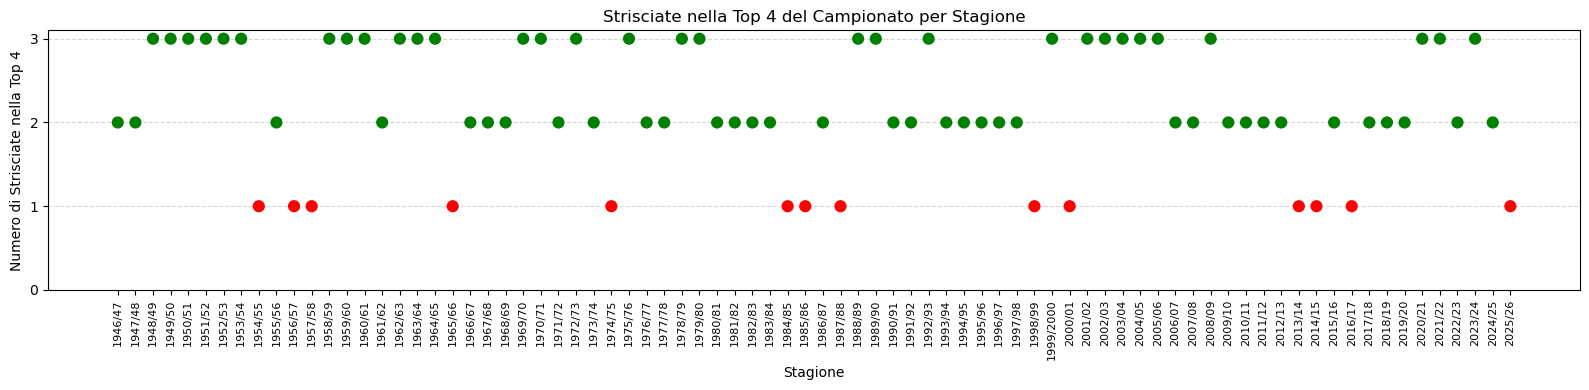

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_strisciate(df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(16, 4))

    colors = strisciate_df["number_of_strisciate"].apply(
        lambda x: "green" if x > 1 else "red"
    )

    ax.scatter(
        x=strisciate_df["season"],
        y=strisciate_df["number_of_strisciate"],
        c=colors,
        s=60,
        zorder=3,
    )

    ax.set_xticks(strisciate_df["season"])
    ax.set_xticklabels(strisciate_df["season"], rotation=90, fontsize=8)
    ax.set_yticks([0, 1, 2, 3])
    ax.set_ylabel("Numero di Strisciate nella Top 4")
    ax.set_xlabel("Stagione")
    ax.set_title("Strisciate nella Top 4 del Campionato per Stagione")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_strisciate(strisciate_df)


Dal grafico si nota come dagli anni 1990 in poi (contando che nel mezzo c'e' stata anche Calciopoli), solo in 6 occasioni solo una tra Juventus, Milan e Inter e' arrivata tra le prime quattro posizioni. 

## Definizione "stretta" di top 4

Come cambiano i risultati se ora consideriamo le prime 4 posizioni come quelle effettivamente riportate nella classifica finale?

Costruiamo il dataframe che ci permette di rispondere a questa domanda.

In [22]:
def parse_pos(val):
    if pd.isna(val):
        return pd.NA
    return int(re.sub(r'\[.*?\]', '', str(val)).strip())

df["Pos_clean"] = df["Pos"].apply(parse_pos)

records_pos = []
for season, group in df.groupby("season"):
    group = group.copy()

    # Top 4 by Pos
    top4_teams = set(group[group["Pos_clean"] <= 4]["Team"])
    strisciate_in_top4 = [t for t in STRISCIATE if t in top4_teams]

    row_data = {
        "season": season,
        "number_of_strisciate": len(strisciate_in_top4),
        "strisciate": strisciate_in_top4,
    }

    for team in STRISCIATE:
        team_row = group[group["Team"] == team]
        if team_row.empty:
            row_data[f"pos_{team}"] = -1
            row_data[f"pts_{team}"] = -1
        else:
            row_data[f"pos_{team}"] = int(team_row["Pos_clean"].values[0])
            row_data[f"pts_{team}"] = int(team_row["Pts_clean"].values[0])

    records_pos.append(row_data)

strisciate_pos_df = pd.DataFrame(records_pos)
strisciate_pos_df["positions"] = strisciate_pos_df[[f"pos_{t}" for t in STRISCIATE]].values.tolist()
strisciate_pos_df["points"]    = strisciate_pos_df[[f"pts_{t}" for t in STRISCIATE]].values.tolist()
strisciate_pos_df = strisciate_pos_df[["season", "number_of_strisciate", "strisciate", "positions", "points"]]

# Merge both definitions and add flag columns
combined_df = strisciate_pos_df.merge(
    strisciate_df[["season", "number_of_strisciate"]],
    on="season",
    suffixes=("_pos", "_pts")
)
combined_df["definition_differs"] = (
    combined_df["number_of_strisciate_pos"] != combined_df["number_of_strisciate_pts"]
)
combined_df["strisciate_absent"] = strisciate_pos_df["positions"].apply(
    lambda p: any(x == -1 for x in p)
)

combined_df.head()

,season,number_of_strisciate_pos,strisciate,positions,points,number_of_strisciate_pts,definition_differs,strisciate_absent
0,1946/47,2,"[Juventus, Milan]","[2, 10, 4]","[53, 36, 50]",2,False,False
1,1947/48,2,"[Juventus, Milan]","[3, 12, 2]","[49, 37, 49]",2,False,False
2,1948/49,3,"[Juventus, Inter Milan, Milan]","[4, 2, 3]","[44, 55, 50]",3,False,False
3,1949/50,3,"[Juventus, Inter Milan, Milan]","[1, 3, 2]","[62, 49, 57]",3,False,False
4,1950/51,3,"[Juventus, Inter Milan, Milan]","[3, 2, 1]","[54, 59, 60]",3,False,False


In [23]:
combined_df[combined_df['definition_differs']]

,season,number_of_strisciate_pos,strisciate,positions,points,number_of_strisciate_pts,definition_differs,strisciate_absent
26,1972/73,2,"[Juventus, Milan]","[1, 5, 2]","[45, 37, 44]",3,True,False
33,1979/80,2,"[Juventus, Inter Milan]","[2, 1, 15]","[38, 41, 36]",3,True,False
35,1981/82,1,[Juventus],"[1, 5, 14]","[46, 35, 24]",2,True,False
59,2005/06,2,"[Inter Milan, Milan]","[20, 1, 3]","[91, 76, 58]",3,True,False


I risultati cambiano solo per quanto riguarda i campionati 1972/73; 1979/80; 1981/82 e 2005/06 e solo in un campionato (1981/82), questo influenza la nostra risposta in maniera significativa perche' aggiunge un anno a quelli in cui tra le prime quattro c'e' solo una strisciata. Da notare che ancora ci deve essere una stagione ***senza nemmeno una strisciata***.

In [24]:
combined_df.value_counts("number_of_strisciate_pos").sort_index(ascending=False).reset_index().rename(columns={"number_of_strisciate_pos": "numero di strisciate", "count": "totale"})

,numero di strisciate,totale
0,3,28
1,2,37
2,1,15


In [25]:
combined_df.value_counts("number_of_strisciate_pos", normalize=True).sort_index(ascending=False).reset_index().rename(columns={"number_of_strisciate_pos": "numero di strisciate", "proportion": "percentuale"}  )

,numero di strisciate,percentuale
0,3,0.3500
1,2,0.4625
2,1,0.1875


Le cose cambiano di poco: ovviamente diminuisce di poco il numero di volte in cui tutte e tre le strisciate sono arrivate nei primi 4 posti cosi come aumenta in maniera irrisoria (meno del $2\%$) il numero di volte in cui solo una strisciata e' arrivata tra le prime quattro. 

> Aspettiamo con pazienza il campionato in cui tutte e tre le strisciate non arrivano ai primi 4 posti.